# Tutorial: ROC and AUC
> Created Aug. 2024 for the FSU Course: *Machine Learning in Physics* <br>
> H. B. Prosper<br>


## Introduction

In the notebook `tutorial_2D_binary_classifier`, we built a simple **discriminant** $D(x)$ to classify the points $x \in \mathbb{R}^2$ sampled from two known Gaussians. In this notebook we compare the approximate discriminant to the exact one using two measures: the **Receiver Operating Characteristic** (ROC) curve and the **Area Under the (ROC) Curve** (AUC). The exact discriminant 
\begin{align}
    D(x) & = \frac{\mathcal{N}(x, \mu^{(1)}, \Sigma^{(1)})}{\mathcal{N}(x, \mu^{(1)}, \Sigma^{(1)}) + \mathcal{N}(x, \mu^{(0)}, \Sigma^{(0)})},
\end{align}
where $\mathcal{N}(x, \mu, \Sigma)$ is the probability density function (pdf) of a bivariate normal is approximated by our best-fit model, $f_\widehat{\omega}(x)$.

In [1]:
# standard system modules
import os, sys

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# standard statistical module
import scipy.stats as st

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn

import joblib
import importlib

import drwho.nn as mlp
import drwho.data as dat

# module for shell utilities
import shutil

# update fonts
FONTSIZE = 12
plt.rcParams.update({
    "text.usetex": shutil.which('latex') is not None, 
    "font.family": "sans-serif",
    "font.size": FONTSIZE
})

# set a seed to ensure reproducibility
seed = 128
rnd  = np.random.RandomState(seed)

## Constants

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Available device: {str(DEVICE):4s}')

# file containing parameters of trained model
params_file = 'runs/gauss2d/gauss2d_params.pth' 

Available device: cpu 


## Import exact density

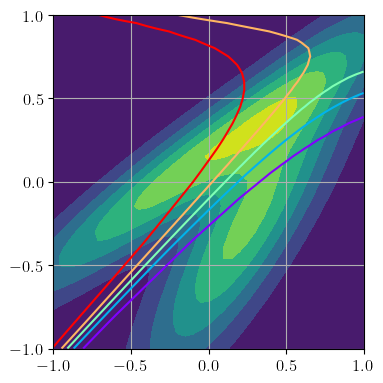

In [3]:
from exactdensity import ExactDensity

fexact = ExactDensity()
fexact.plot()

## Import trained (i.e., fitted) model

In [4]:
import gauss2d

model = gauss2d.model
model.load(params_file)

print(model)
print('number of parameters', mlp.number_of_parameters(model))

Gauss2D(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=2, bias=True)
    (1): Tanh()
    (2): Linear(in_features=2, out_features=1, bias=True)
    (3): Sigmoid()
  )
)
number of parameters 9


## Load test data

In [5]:
test_data = joblib.load('../data/test_data.pth')

test_loader = dat.DataLoader(
    test_data, batch_size=len(test_data))
print(len(test_data))

test_data[:5]

DataLoader
  maxiter:               1
  batch_size:        18000
  shuffle_step:          1

18000


(tensor([[ 0.9125,  0.6928],
         [-0.0575, -0.6689],
         [ 0.2713, -0.3960],
         [ 0.2577,  0.0721],
         [-0.4393, -0.0949]]),
 tensor([[0.],
         [1.],
         [1.],
         [1.],
         [0.]]))

## Compute approximate discriminant values

In [6]:
# 1. detach()   - detach from computational tree
# 2. cpu()      - move to CPU if tensor is not on a CPU, e.g., on a GPU
# 3. numpy()    - convert to numpy array (ndarray)
fapprox = lambda x: model(x).detach().cpu().numpy()

In [7]:
X, Y = next(iter(test_loader))
print('X.shape', X.shape)
print('Y.shape', Y.shape)

# 1. squeeze() - change shape of Y from (n, 1) to (n, )
Y = Y.squeeze()
print('Y.shape', Y.shape)

Dapprox = fapprox(X)

print(Dapprox.shape)

X.shape torch.Size([18000, 2])
Y.shape torch.Size([18000, 1])
Y.shape torch.Size([18000])
(18000, 1)


## Compute exact discriminant values

In [8]:
fexact = ExactDensity()

x1 = X[:, 0] # extract all rows (:) of column 0
x2 = X[:, 1] # extract all rows (:) of column 1

Dexact = fexact.prob(x1, x2)

print(Dexact.shape)

(18000,)


## Plot distributions of discriminant values
What we are doing here is approximating the 1D densities,
\begin{align}
    g(D \mid y) & = \int_{\mathbb{R}^2} \delta(D - f_\widehat{\omega}(x)) \, p(x \mid y) \, dx, \quad y \in \{0,1 \},\\
    & = \mathbb{E}_{p(x\mid y)}\left[ \, \delta(D - f_\widehat{\omega}(x))  \, \right],
\end{align}
using histograms. $g(D \mid y)$ are the **sampling densities** of the discriminant values.

In [24]:
def plot_distribution(D, y, 
                      title=None,
                      nbins=100, 
                      ftsize=FONTSIZE, 
                      fgsize=(5, 5*9/16)):

    # select "positives" (class with y = 1)
    s = D[y > 0.5]
    
    # select "negatives" (class with y = 0)
    b = D[y < 0.5]
    
    # set size of figure
    plt.figure(figsize=fgsize)

    if title:
        plt.title(title)
        
    plt.xlim(0, 1)
    plt.xlabel('$D(x)$')
    
    plt.yscale('log')
    plt.ylabel(r'$p(D\mid y), y=0, 1$')
    
    plt.hist(b, 
             bins=nbins, 
             color='red',
             alpha=0.3,
             range=(0, 1), 
             density=True, 
             label=r'negatives $(y = 1)$') 
    plt.legend(fontsize='small', loc='upper right')
    
    plt.hist(s, 
             bins=nbins, 
             color='blue',
             alpha=0.3,
             range=(0, 1), 
             density=True, 
             label=r'positives $(y = 0)$')
    plt.legend(fontsize='small', loc='upper right')

    plt.savefig("D_distribution.png")
    plt.show()

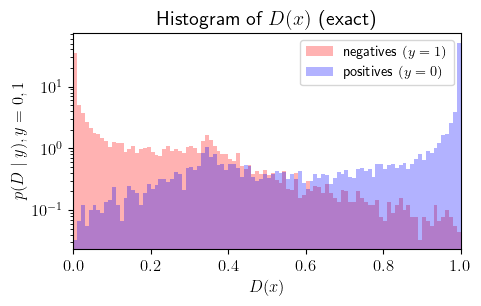

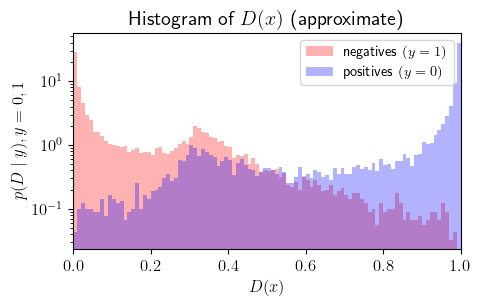

In [25]:
plot_distribution(Dexact, Y, 'Histogram of $D(x)$ (exact)')
plot_distribution(Dapprox, Y, 'Histogram of $D(x)$ (approximate)')

## Compute ROC and AUC

First compute

\begin{align}
    c_y(D) & = \int_{D}^{1} g(z \mid y) \, dz,\quad y \in \{0, 1\},
\end{align}

that is, the fraction of positives or negatives with discriminant values exceeding a given discriminant value $D$, that is, the **true positive rate** (TPR) and the **false positive rate** (FPR), respectively. The ROC curve is a plot of the TPR versus FPR and the AUC is simply the area beneath it. 

In [33]:
# standard measures of model performance
from sklearn.metrics import roc_curve, auc

def plot_ROC(y, D, title=None):

    # compute number of false and true positives for
    # different discriminant values D
    false_positives, true_positives, _ = roc_curve(y, D)

    # compute area under curve
    roc_auc = auc(false_positives, true_positives)
    
    plt.figure(figsize=(3.5, 3.5))

    if title:
        plt.title(title)
        
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('false positive rate (FPR)', fontsize=12)
    plt.ylabel('true positive rate (TPR)', fontsize=12)
    
    plt.plot(false_positives, true_positives, color='red',
             lw=1, label='ROC curve, AUC = %0.2f)' % roc_auc)
    
    plt.plot([0, 1], [0, 1], color='blue', lw=1, linestyle='--')

    plt.legend(loc="lower right", fontsize=11)
    
    plt.savefig("ROC.png")
    plt.show()

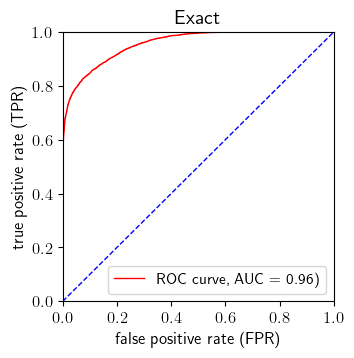

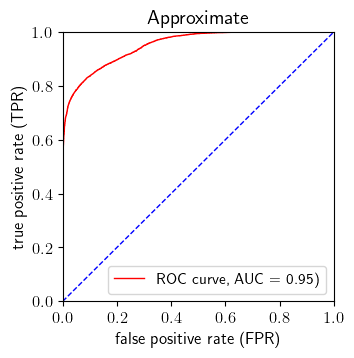

In [35]:
plot_ROC(Y, Dexact, 'Exact')
plot_ROC(Y, Dapprox, 'Approximate')